<a href="https://colab.research.google.com/github/yasmine-vet-ads/Us.Vet.Imagens.Anonimizador/blob/main/notebooks/UsVet_Anonimizador_MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Us.Vet.Imagens.Anonimizador

MVP para anonimização de imagens ultrassonográficas veterinárias.

Objetivo: remover automaticamente áreas com dados sensíveis presentes em imagens de ultrassom, como nome do paciente, tutor, clínica, data e número do exame.

Este projeto faz parte do portfólio técnico em Análise e Desenvolvimento de Sistemas, com foco em VetTech, processamento de imagens, privacidade de dados e automação aplicada à rotina em diagnóstico por imagem veterinário.

SyntaxError: invalid syntax (1369908377.py, line 3)

In [4]:
!pip install opencv-python-headless pillow matplotlib numpy

In [5]:
from google.colab import files
from PIL import Image
from io import BytesIO
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import zipfile

In [13]:
def carregar_imagem(arquivo):
    """
    Carrega uma imagem enviada no Colab e converte para RGB.
    """
    imagem = Image.open(BytesIO(arquivo)).convert("RGB")
    return imagem


def pil_para_array(imagem):
    """
    Converte imagem PIL para array NumPy.
    """
    return np.array(imagem)


def array_para_pil(array):
    """
    Converte array NumPy para imagem PIL.
    """
    return Image.fromarray(array.astype("uint8"))


def aplicar_tarja_preta(regiao):
    """
    Aplica tarja preta na região selecionada.
    """
    return np.zeros_like(regiao)


def aplicar_desfoque(regiao):
    """
    Aplica desfoque na região selecionada.
    """
    altura, largura = regiao.shape[:2]

    if altura == 0 or largura == 0:
        return regiao

    kernel = max(21, ((min(altura, largura) // 8) * 2) + 1)
    return cv2.GaussianBlur(regiao, (kernel, kernel), 0)


def aplicar_pixelizacao(regiao, tamanho_pixel=12):
    """
    Aplica pixelização na região selecionada.
    """
    altura, largura = regiao.shape[:2]

    if altura == 0 or largura == 0:
        return regiao

    reduzida = cv2.resize(
        regiao,
        (max(1, largura // tamanho_pixel), max(1, altura // tamanho_pixel)),
        interpolation=cv2.INTER_LINEAR
    )

    pixelizada = cv2.resize(
        reduzida,
        (largura, altura),
        interpolation=cv2.INTER_NEAREST
    )

    return pixelizada


def anonimizar_regiao(imagem_array, x1, y1, x2, y2, modo="tarja"):
    """
    Aplica anonimização em uma região retangular da imagem.
    """
    saida = imagem_array.copy()

    altura, largura = saida.shape[:2]

    x1 = max(0, min(x1, largura))
    x2 = max(0, min(x2, largura))
    y1 = max(0, min(y1, altura))
    y2 = max(0, min(y2, altura))

    if x2 <= x1 or y2 <= y1:
        return saida

    regiao = saida[y1:y2, x1:x2]

    if modo == "tarja":
        saida[y1:y2, x1:x2] = aplicar_tarja_preta(regiao)
    elif modo == "desfoque":
        saida[y1:y2, x1:x2] = aplicar_desfoque(regiao)
    elif modo == "pixelizacao":
        saida[y1:y2, x1:x2] = aplicar_pixelizacao(regiao)
    else:
        saida[y1:y2, x1:x2] = aplicar_tarja_preta(regiao)

    return saida


def anonimizar_imagem(
    imagem,
    modo="tarja",
    faixa_superior=12,
    faixa_inferior=0,
    lateral_esquerda=0,
    lateral_direita=0
):
    """
    Aplica anonimização por faixas percentuais da imagem.

    Parâmetros em porcentagem:
    - faixa_superior
    - faixa_inferior
    - lateral_esquerda
    - lateral_direita
    """
    imagem_array = pil_para_array(imagem)
    altura, largura = imagem_array.shape[:2]

    saida = imagem_array.copy()

    topo = int(altura * faixa_superior / 100)
    rodape = int(altura * faixa_inferior / 100)
    esquerda = int(largura * lateral_esquerda / 100)
    direita = int(largura * lateral_direita / 100)

    if topo > 0:
        saida = anonimizar_regiao(saida, 0, 0, largura, topo, modo)

    if rodape > 0:
        saida = anonimizar_regiao(saida, 0, altura - rodape, largura, altura, modo)

    if esquerda > 0:
        saida = anonimizar_regiao(saida, 0, 0, esquerda, altura, modo)

    if direita > 0:
        saida = anonimizar_regiao(saida, largura - direita, 0, largura, altura, modo)

    return array_para_pil(saida)


def mostrar_antes_depois(original, anonimizada):
    """
    Mostra imagem original e imagem anonimizada lado a lado.
    """
    plt.figure(figsize=(14, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Imagem original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(anonimizada)
    plt.title("Imagem anonimizada")
    plt.axis("off")

    plt.show()

In [11]:
arquivos = files.upload()

Saving 11.png to 11 (1).png


Imagem carregada: 11 (1).png


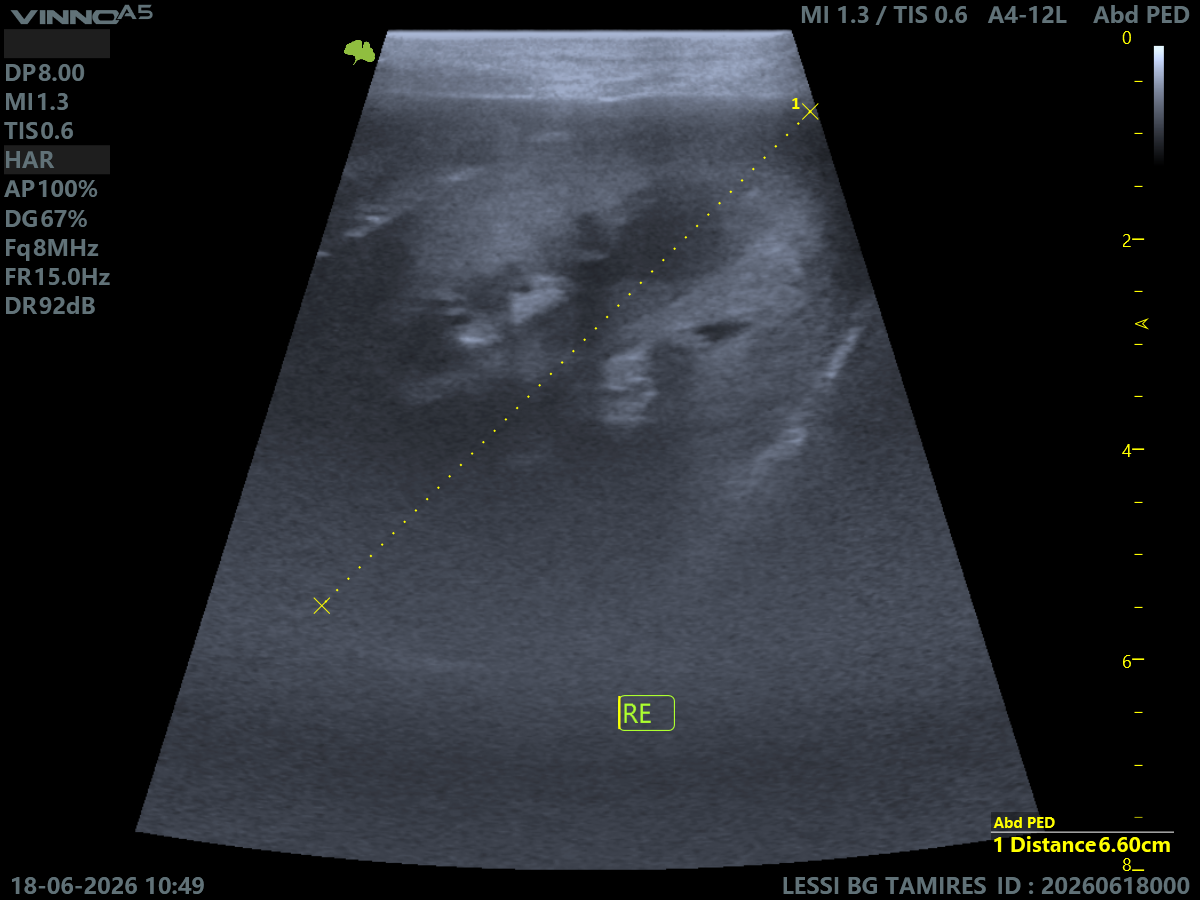

In [12]:
nome_arquivo = list(arquivos.keys())[0]

imagem_original = carregar_imagem(arquivos[nome_arquivo])

print("Imagem carregada:", nome_arquivo)

imagem_original

In [15]:
def anonimizar_canto_inferior_direito(
    imagem,
    modo="tarja",
    largura_percent=45,
    altura_percent=8
):
    """
    Anonimiza apenas o canto inferior direito da imagem.

    largura_percent: porcentagem da largura da imagem coberta a partir da direita.
    altura_percent: porcentagem da altura da imagem coberta a partir da parte inferior.
    """
    imagem_array = pil_para_array(imagem)
    altura, largura = imagem_array.shape[:2]

    x1 = int(largura * (100 - largura_percent) / 100)
    y1 = int(altura * (100 - altura_percent) / 100)
    x2 = largura
    y2 = altura

    imagem_anonimizada = anonimizar_regiao(
        imagem_array,
        x1,
        y1,
        x2,
        y2,
        modo
    )

    return array_para_pil(imagem_anonimizada)

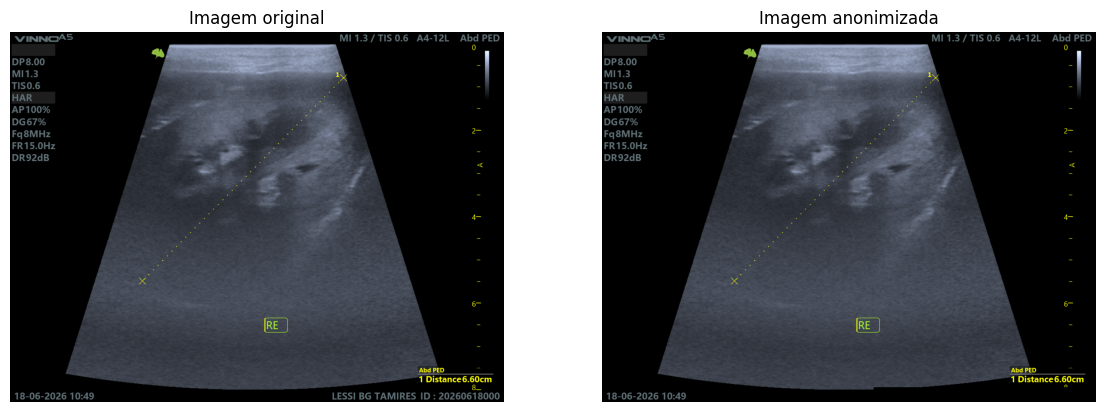

In [17]:
imagem_anonimizada = anonimizar_canto_inferior_direito(
    imagem_original,
    modo="tarja",
    largura_percent=45,
    altura_percent=4
)

mostrar_antes_depois(imagem_original, imagem_anonimizada)

In [18]:
nome_saida = "imagem_anonimizada.png"

imagem_anonimizada.save(nome_saida)

files.download(nome_saida)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>